<a href="https://colab.research.google.com/github/hmultani13/FakeNews_dataset/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install pandas scikit-learn nltk tensorflow matplotlib seaborn


In [15]:
from google.colab import files
uploaded = files.upload()


Saving news.csv to news.csv


In [13]:
import nltk

# Download the stopwords corpus
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [16]:
import pandas as pd

# Load the dataset
df = pd.read_csv('news.csv')

# Display the first few rows of the dataset
df.head()


,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define the neural network model
model = Sequential([
    Dense(512, input_dim=X_train.shape[1], activation='relu'),  # First layer with 512 neurons
    Dropout(0.5),  # Dropout layer to avoid overfitting
    Dense(256, activation='relu'),  # Second layer with 256 neurons
    Dropout(0.5),  # Dropout layer again
    Dense(1, activation='sigmoid')  # Output layer with a sigmoid activation function (binary classification)
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model on the training data
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")


Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.7283 - loss: 0.5265 - val_accuracy: 0.9305 - val_loss: 0.1722
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9644 - loss: 0.1109 - val_accuracy: 0.9337 - val_loss: 0.1954
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9884 - loss: 0.0424 - val_accuracy: 0.9337 - val_loss: 0.2052
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9965 - loss: 0.0132 - val_accuracy: 0.9353 - val_loss: 0.2353
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9999 - loss: 0.0046 - val_accuracy: 0.9337 - val_loss: 0.2658
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9337 - loss: 0.2459
Test Accuracy: 93.37%


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


   Unnamed: 0                                              title  \
0        8476                       You Can Smell Hillary’s Fear   
1       10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2        3608        Kerry to go to Paris in gesture of sympathy   
3       10142  Bernie supporters on Twitter erupt in anger ag...   
4         875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.7495 - loss: 0.5252 - val_accuracy: 0.9258 - val_loss: 0.1731
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9576 - loss: 0.1147 - val_accuracy: 0.9376 - val_loss: 0.1652
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9880 - loss: 0.0442 - val_accuracy: 0.9369 - val_loss: 0.1939
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9979 - loss: 0.0139 - val_accuracy: 0.9361 - val_loss: 0.2251
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9996 - loss: 0.0046 - val_accuracy: 0.9369 - val_loss: 0.2395
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9359 - loss: 0.2313
Test Accuracy: 93.69%


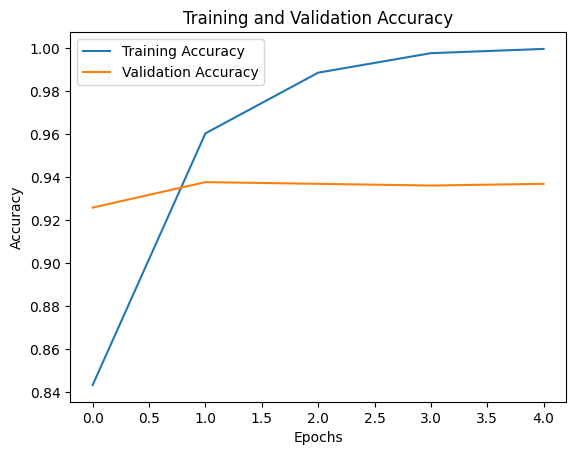

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt

# Download NLTK stopwords
nltk.download('stopwords')

# Load the dataset
df = pd.read_csv('news.csv')  # Load the CSV file with the correct name

# Preview the first few rows of the dataset
print(df.head())

# Assuming 'text' is the column containing the news articles and 'label' contains the labels (REAL or FAKE)
# Clean the text data
def clean_text(text):
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    # Remove special characters (except for letters and spaces)
    text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove stop words (common words that don't add significant meaning)
    text = ' '.join([word for word in text.split() if word not in stopwords.words('english')])
    return text

# Apply the clean_text function to the dataset
df['cleaned_text'] = df['text'].apply(clean_text)

# Vectorize the text data using TF-IDF (Term Frequency-Inverse Document Frequency)
vectorizer = TfidfVectorizer(max_features=5000)  # Limit to top 5000 features
X = vectorizer.fit_transform(df['cleaned_text'])  # Convert text to numeric features

# Convert labels to binary (REAL -> 1, FAKE -> 0)
y = df['label'].apply(lambda x: 1 if x == 'REAL' else 0)

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the neural network model
model = Sequential([
    Dense(512, input_dim=X_train.shape[1], activation='relu'),  # First layer with 512 neurons
    Dropout(0.5),  # Dropout layer to avoid overfitting
    Dense(256, activation='relu'),  # Second layer with 256 neurons
    Dropout(0.5),  # Dropout layer again
    Dense(1, activation='sigmoid')  # Output layer with a sigmoid activation function (binary classification)
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model on the training data
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Plot the accuracy during training
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


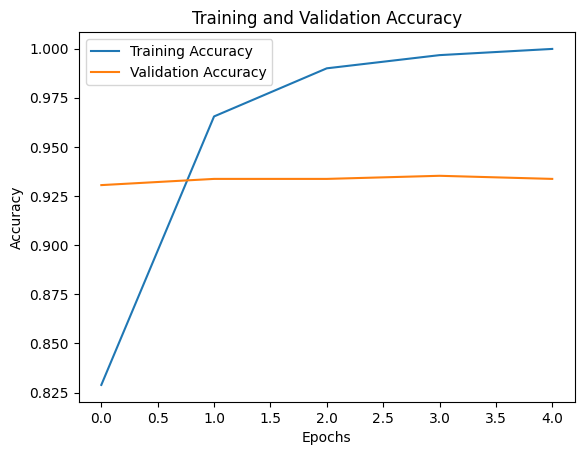

In [ ]:
import matplotlib.pyplot as plt

# Plot the accuracy during training
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
# Making predictions on the test data
y_pred = model.predict(X_test)

# Convert predictions from probabilities to class labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype("int32")

# Evaluate the predictions (Accuracy, Precision, Recall)
from sklearn.metrics import accuracy_score, classification_report

# Calculate accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred_labels)*100:.2f}%")

# Print classification report (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred_labels))


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Accuracy: 93.37%
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       628
           1       0.92      0.95      0.94       639

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267



/tmp/ipython-input-16-3103619431.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x='Unnamed: 0', y='label', inner='box', palette='Dark2')


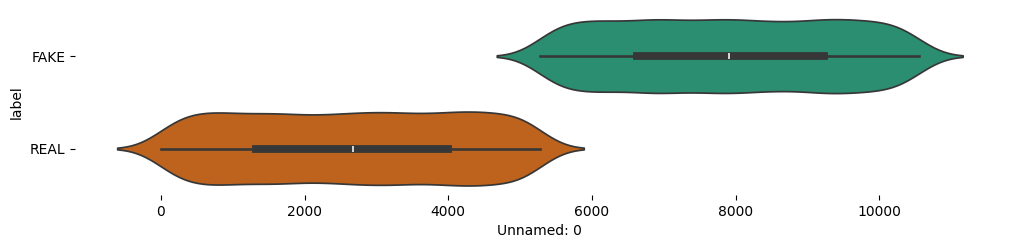

In [ ]:
# @title label vs Unnamed: 0

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df['label'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='Unnamed: 0', y='label', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [18]:
import nltk
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import re

# Download the NLTK stopwords if you haven't
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Function to clean text (remove special characters, stop words, etc.)
def clean_text(text):
    text = re.sub(r'http\S+', '', text)  # Remove URLs
    text = re.sub(r'[^A-Za-z0-9\s]', '', text)  # Remove non-alphanumeric characters
    text = text.lower()  # Convert to lowercase
    text = ' '.join([word for word in text.split() if word not in stop_words])  # Remove stop words
    return text

# Apply the clean_text function to the 'text' column
df['cleaned_text'] = df['text'].apply(clean_text)

# Split the dataset into features (X) and labels (y)
X = df['cleaned_text']
y = df['label'].apply(lambda x: 1 if x == 'REAL' else 0)  # 1 for REAL, 0 for FAKE

# Split the data into training and test sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the training data, and transform the test data
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define the model architecture
model = Sequential([
    Dense(512, input_dim=X_train_tfidf.shape[1], activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary output (fake or real)
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_tfidf, y_train, epochs=5, batch_size=64, validation_data=(X_test_tfidf, y_test))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.7651 - loss: 0.5279 - val_accuracy: 0.9250 - val_loss: 0.1738
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.9634 - loss: 0.1045 - val_accuracy: 0.9298 - val_loss: 0.1866
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9913 - loss: 0.0401 - val_accuracy: 0.9337 - val_loss: 0.2003
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9973 - loss: 0.0114 - val_accuracy: 0.9305 - val_loss: 0.2394
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9997 - loss: 0.0048 - val_accuracy: 0.9353 - val_loss: 0.2563


In [21]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_tfidf, y_test)
print(f'Test Accuracy: {accuracy*100:.2f}%')

# Optionally, you can also make predictions
y_pred = (model.predict(X_test_tfidf) > 0.5)  # Convert probabilities to binary predictions


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9320 - loss: 0.2343
Test Accuracy: 93.53%
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


              precision    recall  f1-score   support

           0       0.93      0.92      0.92       628
           1       0.92      0.93      0.93       639

    accuracy                           0.93      1267
   macro avg       0.93      0.92      0.93      1267
weighted avg       0.93      0.93      0.93      1267



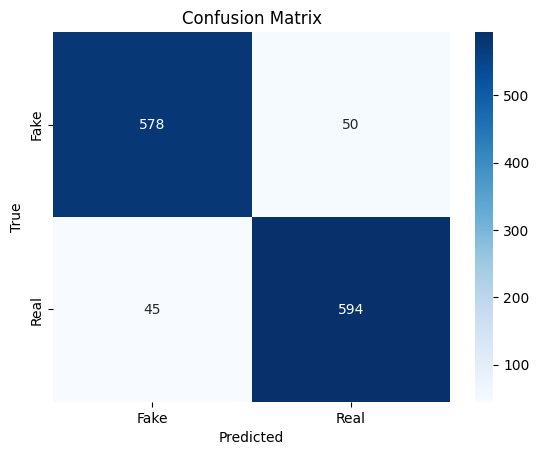

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate classification report
print(classification_report(y_test, y_pred))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
